In [1]:
import numpy as np 
import pandas as pd 
import warnings

warnings.filterwarnings('ignore')

In [74]:
df = pd.read_csv('bbc_news.csv')

In [3]:
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [75]:
df['text'] = df['title'] + ' ' + df['description']

In [47]:
df['text'].isnull().sum()

np.int64(0)

# Preprocess the text 

In [76]:
df['text'] = df['text'].apply(
    lambda x : x.lower()
)

In [77]:
import re

def remove_urls(text):
    return re.sub(r'http\S+', '', text)

df['text'] = df['text'].apply(remove_urls)

In [78]:
import re 
def preprocess(txt): 
    txt = re.sub(r"<.*?>", " ", txt)
    return txt
df['text'] = df['text'].apply(preprocess)

In [79]:
import string
def remove_punc(txt):
    txt = txt.translate(str.maketrans('','',string.punctuation))
    return txt
df['text'] = df['text'].apply(remove_punc)

In [80]:
def remove_digit(txt):
    dig = ''
    for i in txt:
        if not i.isdigit():
            dig = dig + i
    return dig
df['text'] = df['text'].apply(remove_digit)

In [81]:
def remove_emojis(txt):
    new = ''
    for i in txt:
        if i.isascii():
            new = new + i
    return new
df['text'] = df['text'].apply(remove_emojis)

# Remove Stopwords

In [82]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [83]:
stop_words = set(stopwords.words('english'))
def remove_stopwords(txt):
    words = word_tokenize(txt)
    cleaned = []
    for i in words:
        if not i in stop_words:
            cleaned.append(i)
    return cleaned
df['text'] = df['text'].apply(remove_stopwords)

In [84]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

bigram = Phrases(df['text'], min_count=5, threshold=10)
bigram_mod = Phraser(bigram)

df['text'] = df['text'].apply(lambda x: bigram_mod[x])

In [85]:
from gensim import corpora
dictionary = corpora.Dictionary(df['text'])
dictionary.filter_extremes(no_below=5 , no_above=0.5)
corpus = [dictionary.doc2bow(txt) for txt in df['text']]

In [86]:
from gensim.models import LdaModel
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary, 
    alpha='auto',
    num_topics=5,
    random_state=42
) 

In [87]:
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopic {idx}:")
    print(topic)


Topic 0:
0.008*"says" + 0.008*"people" + 0.007*"uk" + 0.006*"new" + 0.005*"say" + 0.004*"could" + 0.004*"us" + 0.004*"police" + 0.003*"killed" + 0.003*"told"

Topic 1:
0.009*"says" + 0.007*"us" + 0.006*"man" + 0.005*"former" + 0.004*"star" + 0.004*"life" + 0.004*"family" + 0.004*"years" + 0.003*"police" + 0.003*"killed"

Topic 2:
0.020*"says" + 0.015*"england" + 0.011*"election" + 0.005*"wales" + 0.005*"new" + 0.005*"first" + 0.004*"scotland" + 0.004*"englands" + 0.003*"former" + 0.003*"pitch"

Topic 3:
0.010*"premier_league" + 0.010*"gaza" + 0.009*"israel" + 0.007*"win" + 0.007*"says" + 0.006*"liverpool" + 0.006*"manchester_city" + 0.006*"world_snooker" + 0.005*"club" + 0.005*"strikes"

Topic 4:
0.009*"says" + 0.008*"budget" + 0.008*"labour" + 0.007*"win" + 0.007*"trump" + 0.006*"pm" + 0.006*"final" + 0.006*"starmer" + 0.005*"euro" + 0.005*"new"


In [88]:
from gensim.models import CoherenceModel

coherence_model = CoherenceModel(
    model=lda_model,
    texts=df['text'],
    dictionary=dictionary,
    coherence='c_v'
)

print("Coherence Score:", coherence_model.get_coherence())

Coherence Score: 0.2916728121250584


In [64]:
def get_dominant_topic(model, corpus):
    topics = []
    for doc in model[corpus]:
        topics.append(sorted(doc, key=lambda x: -x[1])[0][0])
    return topics

df['dominant_topic'] = get_dominant_topic(lda_model, corpus)

In [91]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import matplotlib.pyplot as plt

In [92]:
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

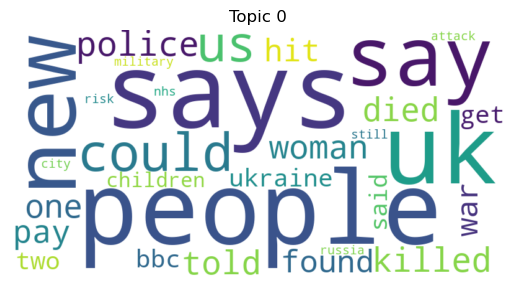

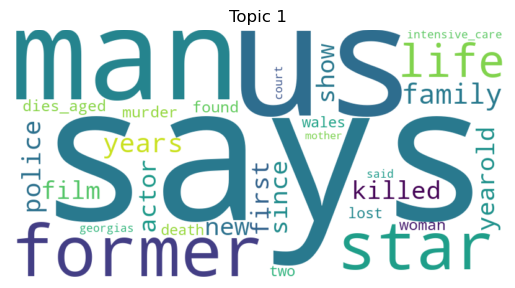

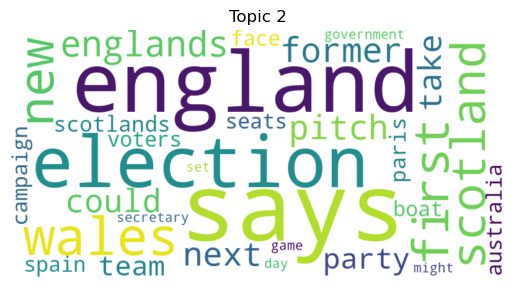

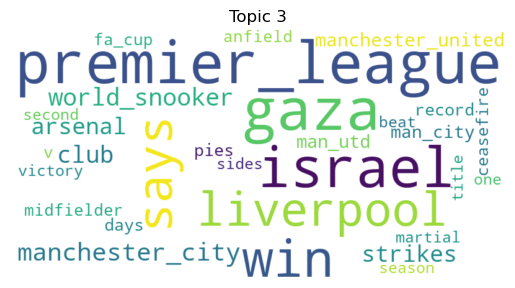

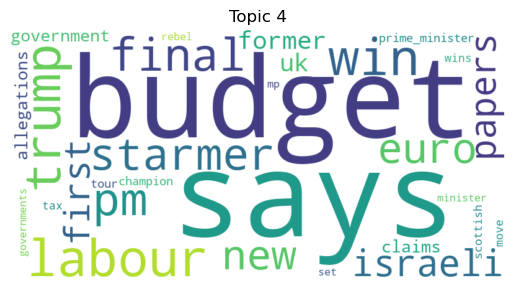

In [94]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

num_topics = lda_model.num_topics

for t in range(num_topics):
    plt.figure()
    
    # Get topic words and weights
    topic_words = dict(lda_model.show_topic(t, 30))
    
    wc = WordCloud(width=800, height=400, background_color='white')
    wc.generate_from_frequencies(topic_words)
    
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Topic {t}")
    plt.show()